# KDUQ corpus: neutron total

The KDUQ corpus is a reconstruction of the experimental data used in the Koning-Delaroche global optical potential analysis, assembled from EXFOR by the supplement's authors and tabulated in Supplemental Material B.

Neutron total cross sections, in barns against incident lab energy. Each data set is trimmed to the energy range the supplement tabulates and downsampled to at most one datum per MeV, following the supplement: the total cross section varies slowly enough over this range that the full complement of energy bins -- nearly 50,000 for one data set -- carries no information an optical model analysis can use.

The subentries and scattering energies below are transcribed from the supplement's
tables into `spec/kduq_neutron_total.csv`. Every row must be accounted for: it either
produces data, or it is listed in `spec/known_missing.csv` with a reason. Uncertainties
are assigned by the supplement's preference rule (`nn_corpora.errors`), and the
corrections its Comments describe are applied from `nn_corpora.overrides`.

In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt

import pandas as pd

from nn_corpora import corpus, plotting, report, spec

pd.set_option("display.max_rows", 200)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## The specification

In [2]:
rows = spec.load_sector('kduq', 'neutron_total')
print(f"{len(rows)} rows, {len({r.subentry for r in rows if r.in_exfor})} distinct subentries")
pd.DataFrame([vars(r) for r in rows]).head(15)

68 rows, 68 distinct subentries


,corpus,sector,projectile,target_A,target_Z,target_label,energy_mev,energy_hi_mev,subentry,pointer,pdf_page
0,kduq,neutron_total,neutron,0,12,natMg,5.293,297.800,13753010,,12
1,kduq,neutron_total,neutron,0,12,natMg,0.008,39.807,10791002,,12
2,kduq,neutron_total,neutron,27,13,27Al,1.999,80.620,12882005,,12
3,kduq,neutron_total,neutron,27,13,27Al,5.293,297.772,13569008,,12
4,kduq,neutron_total,neutron,27,13,27Al,0.935,NaN,21926003,,12
5,kduq,neutron_total,neutron,27,13,27Al,0.250,19.286,22331004,,12
6,kduq,neutron_total,neutron,0,14,natSi,0.187,47.680,10377005,,12
7,kduq,neutron_total,neutron,0,14,natSi,1.996,79.828,12882006,,12
8,kduq,neutron_total,neutron,0,14,natSi,5.293,297.772,13569009,,12
9,kduq,neutron_total,neutron,0,16,natS,2.259,14.888,10047018,,12


## Retrieve and clean

`corpus.curate` retrieves each entry, matches measurements back to the rows that asked
for them, applies the documented corrections, and homogenises units and frames.

In [3]:
result = corpus.curate('kduq', 'neutron_total')
print(result.summary())

kduq/neutron_total
  spec rows              68
  ... marked absent      0
  ... resolved           65 / 68 (95.6%)
  measurements           65
  data points            4497
  EXFOR entries          35
  unresolved by category
    x4i3-parse-failure       3
  serialized             65 measurements, 4497 points


## Rows that did not resolve

Every row listed here must appear in `spec/known_missing.csv`, or the write below will
fail. The categories are: `absent-from-exfor` (the supplement itself marks the row as
not locatable), `x4i3-parse-failure` (the entry is in EXFOR but x4i3 cannot read it),
`subentry-withdrawn` (EXFOR has renumbered or removed the subentry since the supplement
was written), `energy-not-found`, and `uncertainty-unresolved`.

In [4]:
print(report.unresolved_table(result.data))

natCr     0.185 10342004  [x4i3-parse-failure] retrieval failed: XS: AttributeError: 'NoneType' object has no attribute 'total_len'
209Bi     0.011 10449003  [x4i3-parse-failure] retrieval failed: XS: AttributeError: 'NoneType' object has no attribute 'total_len'
natMg     0.008 10791002  [x4i3-parse-failure] uncertainty unresolved (entry-unavailable): entry 10791 is not in the x4i3 index; it is most likely one of the entries x4i3 fails to parse


## Uncertainty audit

Data sets with missing uncertainties are dropped during munging, following the
supplement's removal of any data set lacking a necessary feature. This lists anything
that survived but still looks suspicious.

In [5]:
flags = plotting.check_uncertainties(result)
print("\n".join(flags) if flags else "every measurement carries uncertainties")

every measurement carries uncertainties


## Inspect

Outliers here are found by eye. A mistranscribed point shows up as a single datum an
order of magnitude away from its neighbours; a badly normalised data set shows up as a
whole curve offset from others at the same energy.

... 13 further targets not plotted


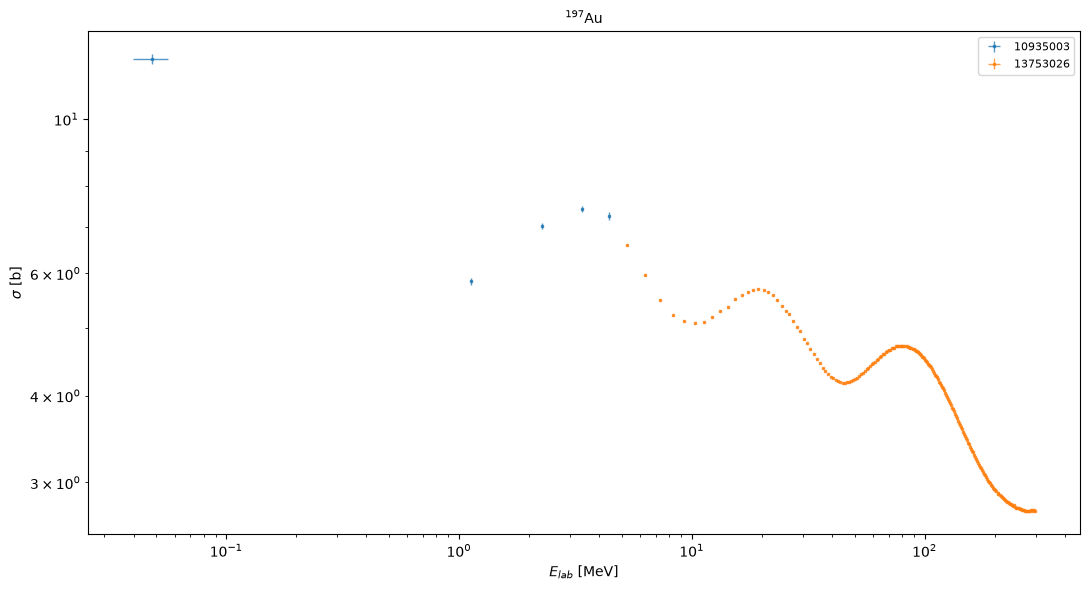

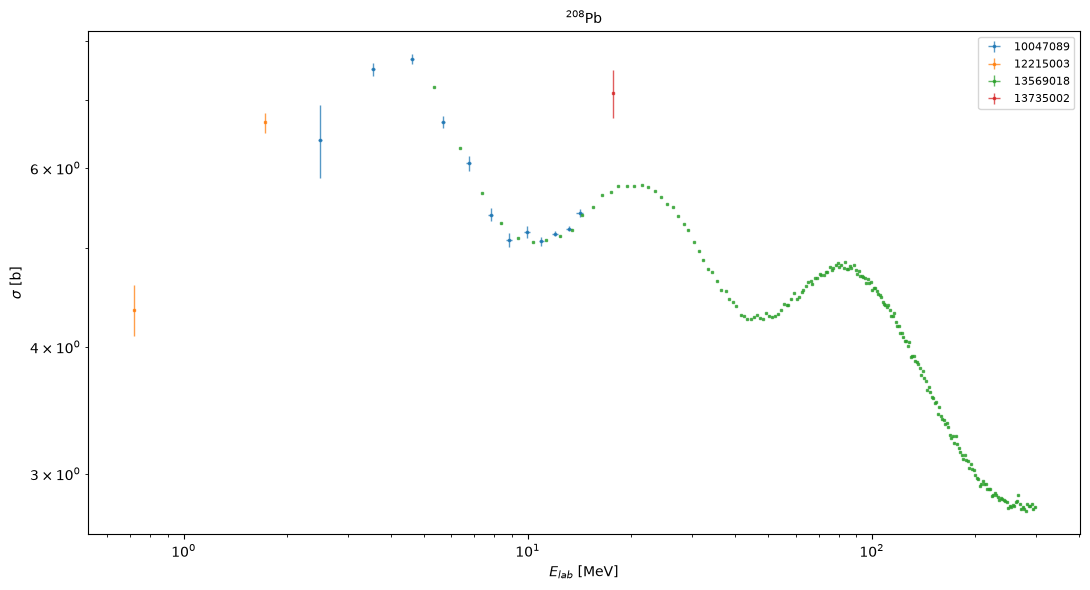

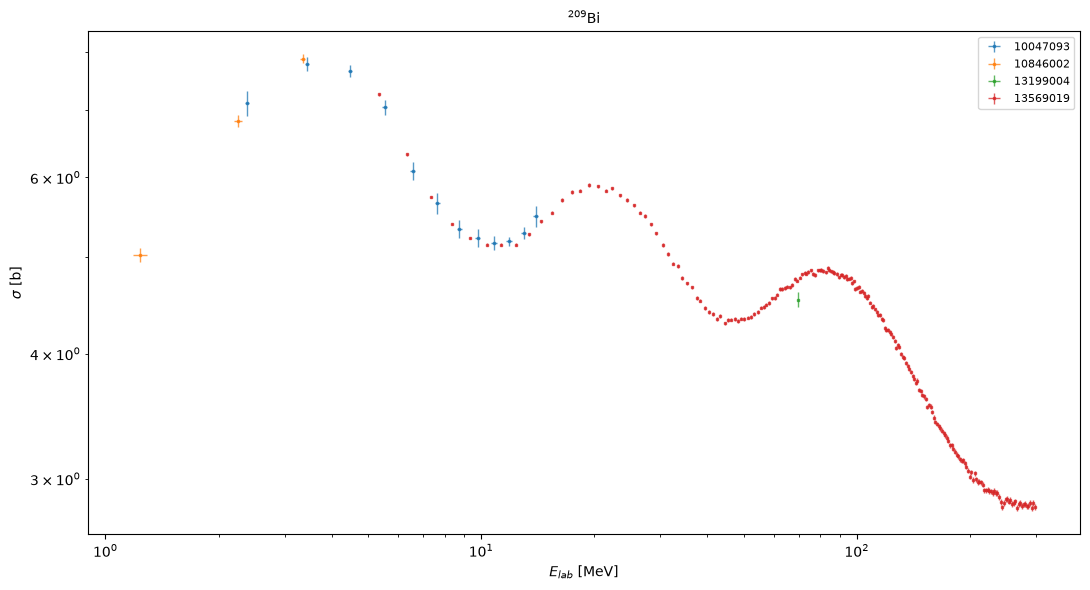

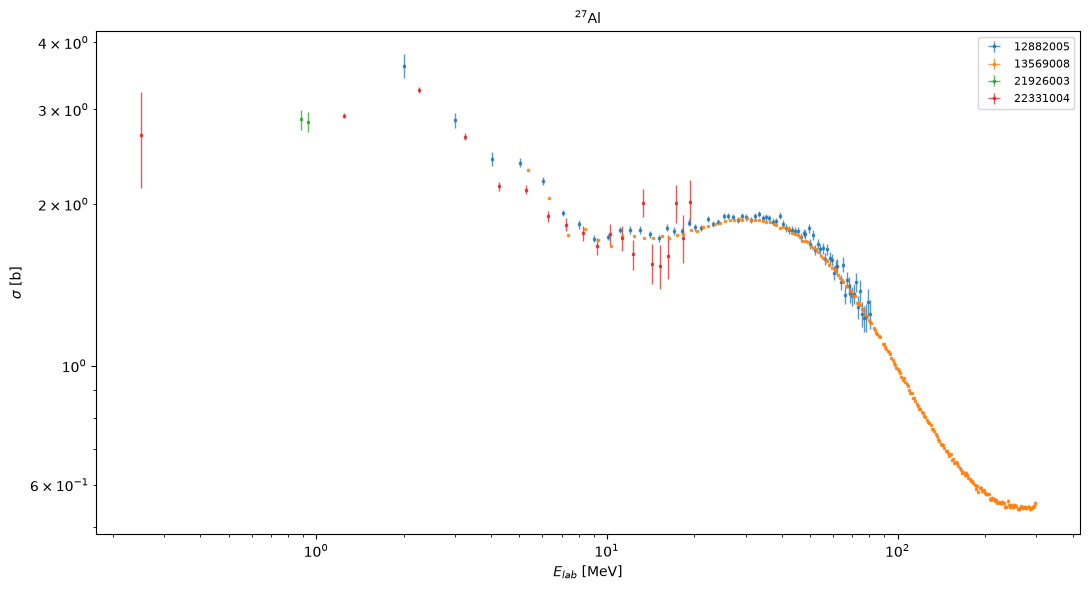

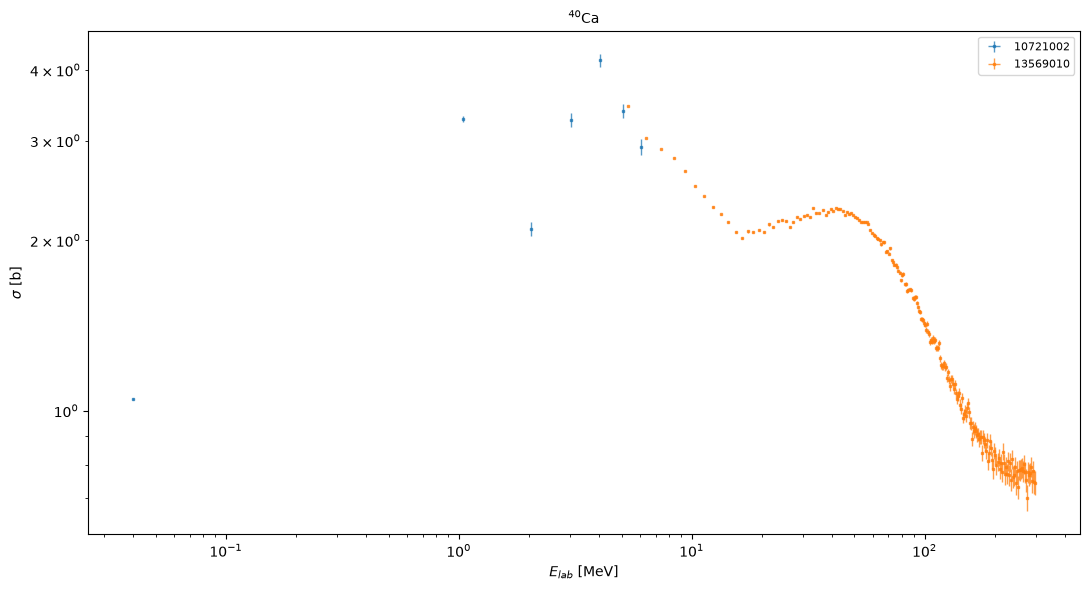

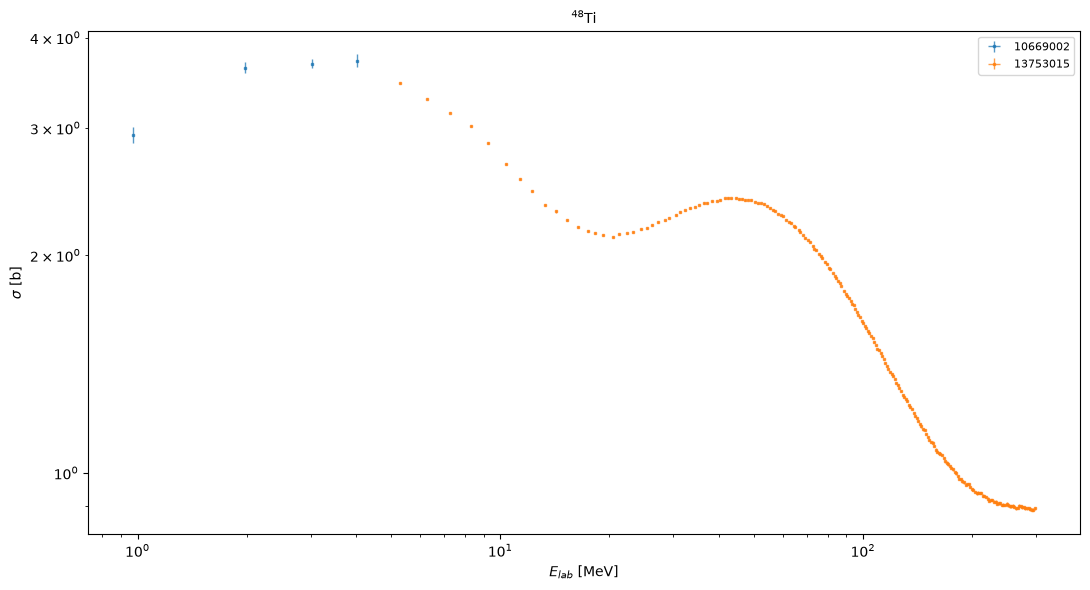

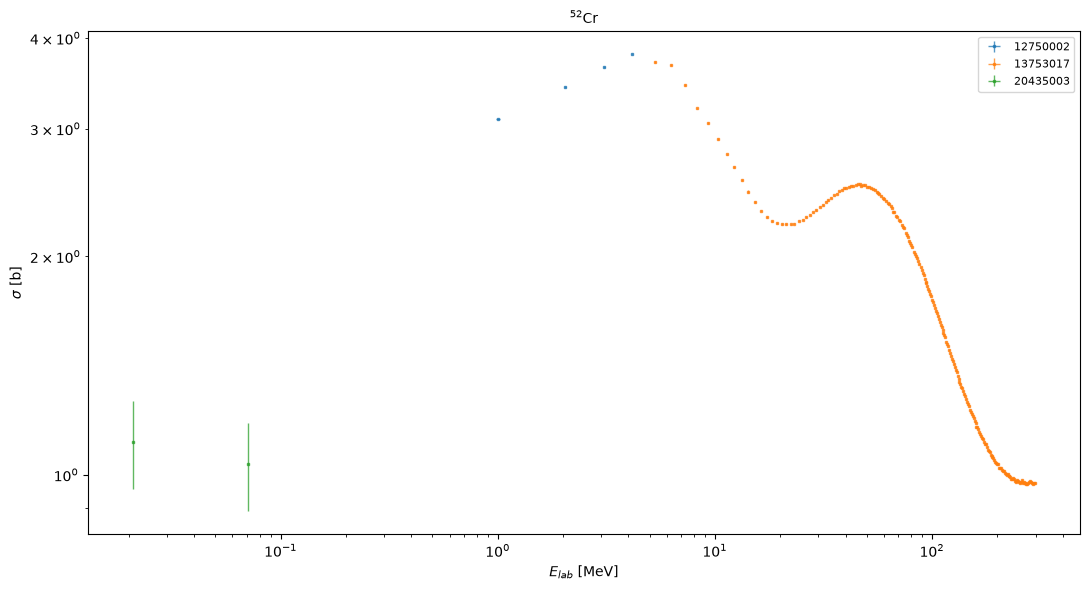

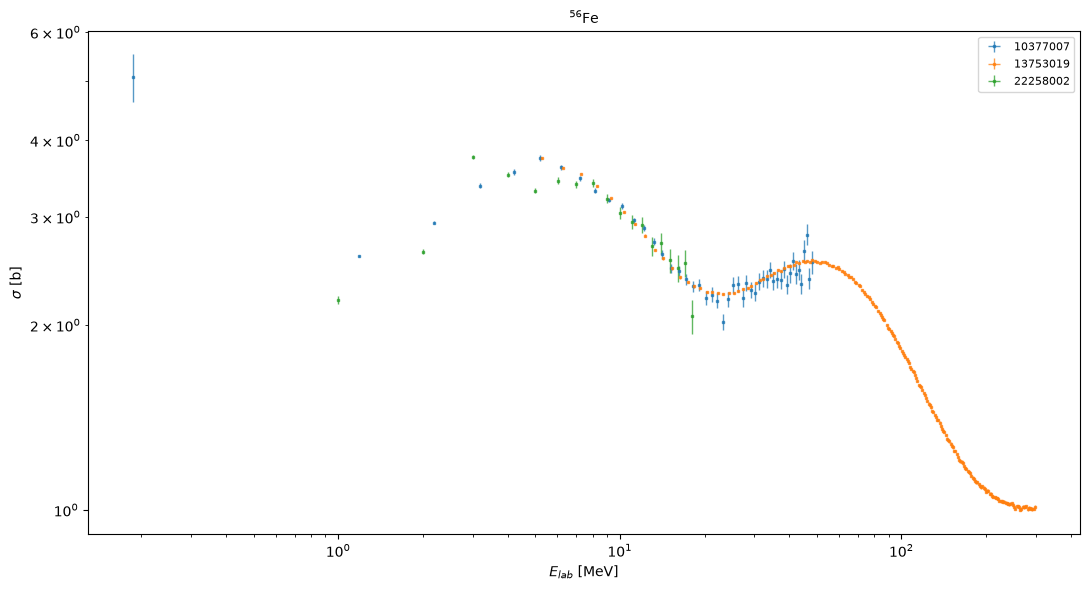

In [6]:
plotting.plot_sector(result, max_targets=8)
plt.show()

## Write

`corpus.write` re-checks coverage against the allowlist before writing, so a data set
that silently disappears from EXFOR fails here rather than passing unnoticed.

In [7]:
corpus.write(result)
print(f"wrote {len(result.records)} measurements to data/{result.corpus}/{result.sector}/")

wrote 65 measurements to data/kduq/neutron_total/
